#  Healthcare Analytics: Stroke Risk Analysis

## Project Objective

Stroke is one of the leading causes of death and long-term disability worldwide. Early identification of high-risk patients can help healthcare providers implement preventive measures and allocate medical resources more effectively.

The objective of this project is to analyze patient demographic and clinical data to identify patterns associated with stroke occurrence using Python for exploratory data analysis and visualization.

---

## Business Problem

Healthcare organizations need to understand:

- Which patient characteristics are associated with stroke?
- Which medical conditions appear most frequently among stroke patients?
- How can these insights support preventive healthcare and resource planning?

---

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn



In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt



# Data Loading

The dataset is imported into Python using Pandas. It contains demographic and clinical information for patients that will be used throughout the analysis.

In [3]:
df = pd.read_csv("D://MIT//Healthcare_Analytics_Project//Data//brain_stroke.csv")


# Data Understanding

Before performing any analysis, it is important to understand the dataset structure.

The following checks are performed:

- Number of rows and columns
- Data types
- Missing values
- Summary statistics

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


In [21]:
df.head()



,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [28]:
df.shape 
#this gives how many rows and how many columns are there
#syntax is rows, col

(4981, 11)

In [8]:
df.describe()
#this gives the count, mean,std,min,max,quartile 


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,43.419859,0.096165,0.055210,105.943562,28.498173,0.049789
std,22.662755,0.294848,0.228412,45.075373,6.790464,0.217531
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,45.000000,0.000000,0.000000,91.850000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.860000,32.600000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


# Data Cleaning

The dataset is examined for missing values, duplicate records, and inconsistent data types.

Since no missing values or duplicate records were identified, no additional cleaning was required before analysis.

In [ ]:

df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [11]:
df["stroke"].value_counts()

stroke
0    4733
1     248
Name: count, dtype: int64

## Class Distribution

This section examines the distribution of categorical variables to understand the composition of the dataset before conducting further analysis.

### Distribution of Stroke Cases

The value_counts(normalize=True) function is used to calculate the percentage distribution of stroke cases within the dataset.

In [ ]:
df["stroke"].value_counts(normalize =True)*100
#normalize=True gives the proportion of it 
# if you give normalize=False its same as df["stroke"].value_counts()

stroke
0    95.02108
1     4.97892
Name: proportion, dtype: float64

In [25]:
df["hypertension"].value_counts(normalize =True)*100

hypertension
0    90.383457
1     9.616543
Name: proportion, dtype: float64

In [26]:
df["heart_disease"].value_counts(normalize =True)*100

heart_disease
0    94.47902
1     5.52098
Name: proportion, dtype: float64

In [28]:
(df["stroke"].value_counts(normalize=True)*100).round(0)

stroke
0    95.0
1     5.0
Name: proportion, dtype: float64

In [14]:
df["gender"].value_counts()


gender
Female    2907
Male      2074
Name: count, dtype: int64

In [15]:

df["gender"].value_counts(normalize=True)*100

gender
Female    58.361775
Male      41.638225
Name: proportion, dtype: float64

In [16]:

df["smoking_status"].value_counts(normalize=True)*100

smoking_status
never smoked       36.900221
Unknown            30.114435
formerly smoked    17.406143
smokes             15.579201
Name: proportion, dtype: float64

In [17]:

df["work_type"].value_counts(normalize=True)*100

work_type
Private          57.418189
Self-employed    16.141337
children         13.511343
Govt_job         12.929131
Name: proportion, dtype: float64

In [20]:
df["Residence_type"].value_counts(normalize=True)*100

Residence_type
Urban    50.833166
Rural    49.166834
Name: proportion, dtype: float64

In [24]:
df["ever_married"].value_counts(normalize=True)*100

ever_married
Yes    65.850231
No     34.149769
Name: proportion, dtype: float64

In [29]:
df.groupby("stroke")["age"].mean()

stroke
0    42.141348
1    67.819839
Name: age, dtype: float64

In [30]:
df.groupby("stroke")["avg_glucose_level"].mean()

stroke
0    104.569056
1    132.175565
Name: avg_glucose_level, dtype: float64

In [31]:
df.groupby("stroke")["bmi"].mean()


stroke
0    28.409698
1    30.186694
Name: bmi, dtype: float64

### Relationship Analysis

Cross-tabulation is used to compare stroke occurrence across different patient groups and identify potential risk factors.

In [25]:
pd.crosstab(df["hypertension"], df["stroke"], normalize="columns")*100

stroke,0,1
hypertension,,
0,91.274033,73.387097
1,8.725967,26.612903


In [26]:
pd.crosstab(df["heart_disease"], df["stroke"], normalize="columns")*100

stroke,0,1
heart_disease,,
0,95.182759,81.048387
1,4.817241,18.951613


In [27]:
df.groupby("stroke")["age"].mean()

stroke
0    42.141348
1    67.819839
Name: age, dtype: float64

stroke patients are significantly older 

 mean: 67.8
 

In [28]:
df.groupby("stroke")["heart_disease"].mean()

stroke
0    0.048172
1    0.189516
Name: heart_disease, dtype: float64

stroke patients who has heart diseases are .18%

In [29]:
df.groupby("stroke")["bmi"].mean()


stroke
0    28.409698
1    30.186694
Name: bmi, dtype: float64

the stroke patients whose bmi is slightly higher than non-stroke pateints


In [30]:
df.groupby("stroke")["avg_glucose_level"].mean()

stroke
0    104.569056
1    132.175565
Name: avg_glucose_level, dtype: float64

Stroke patients exhibit significantly higher average glucose levels than the overall population.

In [31]:
df.groupby("stroke")[["bmi","age","avg_glucose_level"]].mean()


,bmi,age,avg_glucose_level
stroke,,,
0,28.409698,42.141348,104.569056
1,30.186694,67.819839,132.175565


In [33]:
pd.crosstab(df["smoking_status"],df["stroke"], normalize ="columns")*100

stroke,0,1
smoking_status,,
Unknown,30.699345,18.951613
formerly smoked,16.839214,28.225806
never smoked,36.953307,35.887097
smokes,15.508134,16.935484


In [3]:
pd.crosstab(df["gender"], df["stroke"], normalize="columns")*100

stroke,0,1
gender,,
Female,58.461864,56.451613
Male,41.538136,43.548387


In [6]:
pd.crosstab(df["work_type"], df["stroke"], normalize="columns")*100

stroke,0,1
work_type,,
Govt_job,12.909360,13.306452
Private,57.299810,59.677419
Self-employed,15.613776,26.209677
children,14.177055,0.806452


In [7]:
pd.crosstab(df["Residence_type"], df["stroke"], normalize = "columns")*100

stroke,0,1
Residence_type,,
Rural,49.355588,45.564516
Urban,50.644412,54.435484


### Data Cleaning

The smoking status column contained "Unknown" values. Since children aged 14 years or younger are unlikely to have a smoking history, these records were recategorized as "Never Smoked" to improve data quality

In [10]:
n = (df["smoking_status"] == "Unknown").sum()
print("before cleaning:",n)

before cleaning: 1500


In [14]:
p = df.loc[(df["smoking_status"] == "Unknown") & (df["age"] <= 14), "smoking_status"] = "never smoked"

print("after cleaning:", (df["smoking_status"] == "Unknown").sum())

after cleaning: 903


In [15]:
pd.crosstab(df["smoking_status"], df["stroke"], normalize="columns") * 100

stroke,0,1
smoking_status,,
Unknown,18.128037,18.145161
formerly smoked,16.839214,28.225806
never smoked,49.524614,36.693548
smokes,15.508134,16.935484


In [17]:
p = df.loc[(df["smoking_status"] == "Unknown") & (df["age"] >= 10), "smoking_status"] = "never smoked"

print("after cleaning:", (df["smoking_status"] == "Unknown").sum())

after cleaning: 0


In [18]:
pd.crosstab(df["smoking_status"], df["stroke"], normalize="columns") * 100

stroke,0,1
smoking_status,,
formerly smoked,16.839214,28.225806
never smoked,67.652652,54.838710
smokes,15.508134,16.935484


In [ ]:
df.to_csv("StrokeData.csv", index=False)
print("ready")


ready


In [6]:
df = pd.read_csv("D://MIT//Healthcare_Analytics_Project//notebooks//StrokeData.csv")




### 1. How common is stroke among the patients in the dataset?

This visualization compares the number of patients diagnosed with stroke against those without stroke to understand the overall distribution of the target variable.

C:\Users\Elena\AppData\Local\Temp\ipykernel_9504\276250392.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a= sns.countplot(data =df, x="stroke", palette = ["#3498db","#e74c3c"])


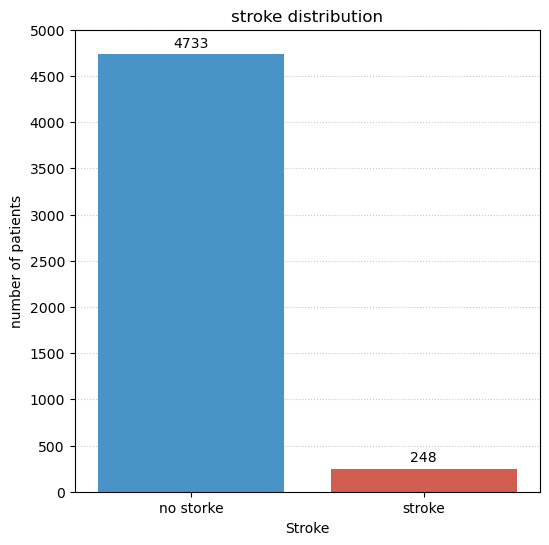

In [ ]:
plt.figure(figsize =(6,6))

a= sns.countplot(data =df, x="stroke", palette = ["#3498db","#e74c3c"])

plt.title("stroke distribution")
plt.xlabel("Stroke")
plt.ylabel("number of patients")

plt.xticks([0,1],["no storke","stroke"])
#manually this is done for y-axis 
# syntax is plt.yticks(range(start, end, steps))
plt.yticks(range(0,5001,500))
#to tell the precise height of the bar 
a.bar_label(a.containers[0], padding = 3)
a.bar_label(a.containers[1], padding = 3)
#grid in the bg
plt.grid(axis="y",linestyle="dotted", alpha=0.7)
#to make sure the lines are behind the bars, try removing the below line of code and see the difference!
a.set_axisbelow(True) 
plt.show()

### Business Insight

The dataset is highly imbalanced, with approximately 95% of patients not experiencing a stroke and only about 5% diagnosed with stroke.

### Business Recommendation

Healthcare providers should prioritize identifying high-risk individuals through targeted screening rather than applying equal attention across the entire patient population.

This class imbalance should also be considered if a predictive machine learning model is developed in the future.



### 2. What is the gender distribution of patients?

Understanding gender distribution helps determine whether the dataset represents both male and female patients adequately.

C:\Users\Elena\AppData\Local\Temp\ipykernel_9504\3616338414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  b =sns.countplot(data=df, x="gender", palette=["#3498db","#e74c3c"])


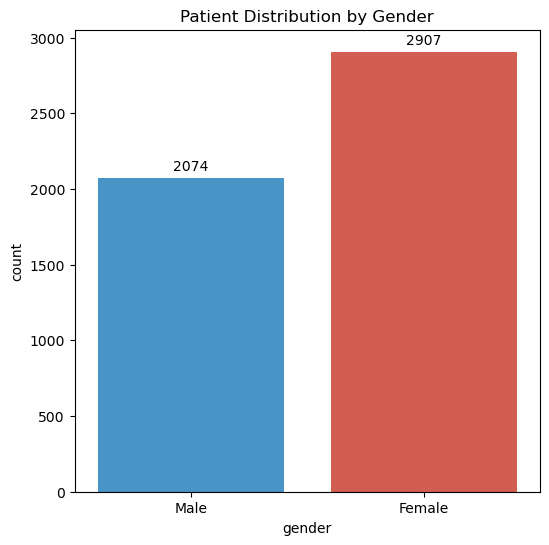

In [ ]:
plt.figure(figsize=(6,6))
b =sns.countplot(data=df, x="gender", palette=["#3498db","#e74c3c"])
plt.title("Patient Distribution by Gender")
plt.yticks(range(0,3001,500))
b.bar_label(b.containers[0], padding = 3)
b.bar_label(b.containers[1], padding = 3)
plt.show()

### Business Insight

The dataset contains a slightly higher proportion of female patients than male patients. However, gender alone does not appear sufficient to explain stroke occurrence.

### Business Recommendation

Gender should be analyzed together with clinical factors such as age, hypertension, heart disease, and glucose level when assessing stroke risk.



### 3.What does the age distribution of patients look like?

Age is one of the most widely recognized factors associated with stroke risk. This visualization explores how patient ages are distributed across the dataset.

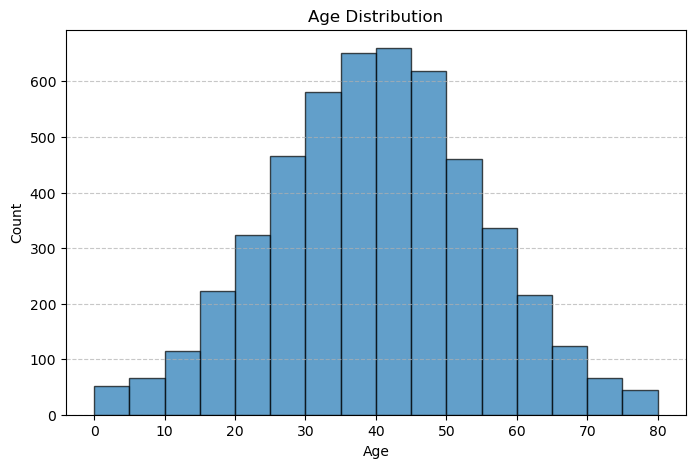

In [ ]:
# to keep the age distribution in ascending order
np.random.seed(42)
ages = np.random.normal(loc=40, scale=15, size=5000)
ages = np.clip(ages, 0, 80)

plt.figure(figsize=(8,5))
plt.hist(ages, bins=16, edgecolor='black', alpha=0.7)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Business Insight

The dataset includes patients across a wide age range, with a larger concentration of middle-aged and older adults. Since stroke risk generally increases with age, this distribution supports further investigation into age-related stroke patterns.

### Business Recommendation

Healthcare providers should consider implementing age-based screening programs and regular health assessments for older adults.



### 4. Does average age differ between stroke and non-stroke patients?

Comparing average age between the two groups helps determine whether age is associated with stroke occurrence.

C:\Users\Elena\AppData\Local\Temp\ipykernel_9504\2422090774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  d = sns.barplot(data=df, x="stroke", y="age", palette=["#3498db","#e74c3c"], errorbar=None)


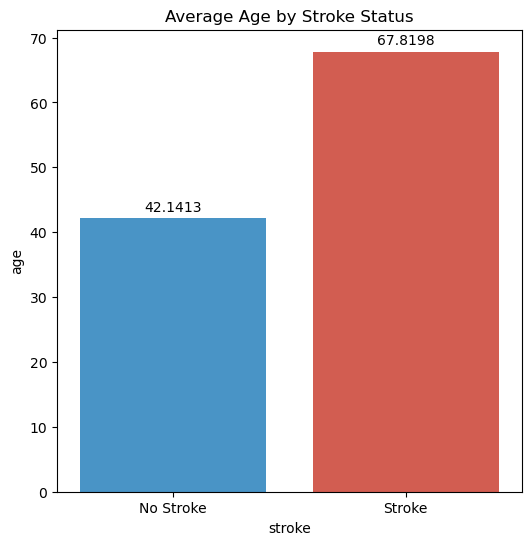

In [ ]:
plt.figure(figsize=(6,6))

d = sns.barplot(data=df, x="stroke", y="age", palette=["#3498db","#e74c3c"], errorbar=None)
plt.xticks([0,1],["No Stroke","Stroke"])
plt.title("Average Age by Stroke Status")
d.bar_label(d.containers[0], padding = 3)
d.bar_label(d.containers[1], padding = 3)
plt.show()

### Business Insight

Patients diagnosed with stroke have a significantly higher average age (67.82 years) compared to patients without stroke (42.14 years).

This indicates that age is one of the strongest factors associated with stroke occurrence within this dataset.

### Business Recommendation

Preventive healthcare initiatives should prioritize elderly patients through routine screenings and early intervention programs.


### 5. How is Body Mass Index (BMI) distributed among patients?

BMI is commonly associated with lifestyle-related health conditions that may contribute to stroke risk.

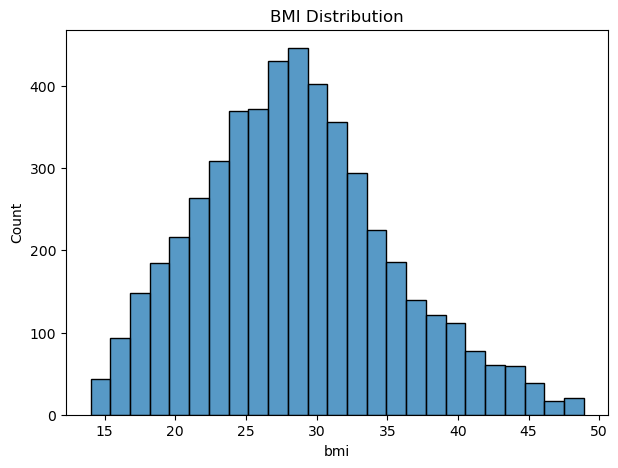

In [ ]:
# to keep the age distribution in ascending order
np.random.seed(42)
ages = np.random.normal(loc=40, scale=26, size=5000)
ages = np.clip(ages, 0, 80)


plt.figure(figsize = (7,5))
sns.histplot(df["bmi"], bins = 25)
plt.title("BMI Distribution")
plt.show()

### Business Insight

Most patients fall within the overweight BMI range. The distribution suggests that elevated BMI is common across the patient population.

### Business Recommendation

Healthcare organizations should continue promoting healthy lifestyle programs focused on nutrition and physical activity to reduce obesity-related health risks.


### 6. Do stroke patients have a higher average BMI?

Comparing average BMI between stroke and non-stroke patients helps evaluate whether body weight may be associated with stroke occurrence.

C:\Users\Elena\AppData\Local\Temp\ipykernel_9504\672240163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  e=sns.barplot(data = df, x="stroke", y="bmi", palette = ["#3498db","#e74c3c"], errorbar=None)


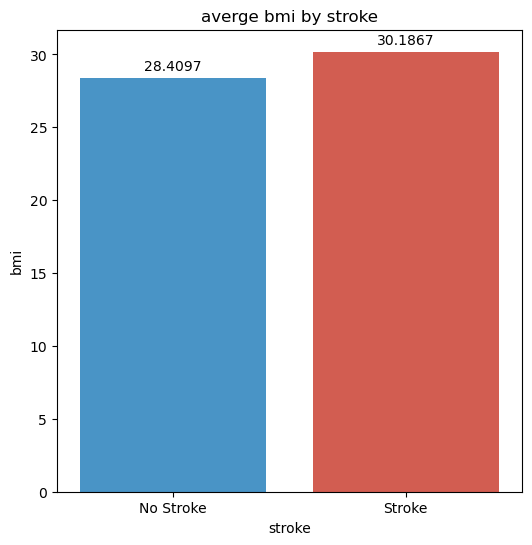

In [ ]:
plt.figure(figsize=(6,6))
e=sns.barplot(data = df, x="stroke", y="bmi", palette = ["#3498db","#e74c3c"], errorbar=None)
plt.xticks([0,1],["No Stroke","Stroke"])
plt.title("averge bmi by stroke")
e.bar_label(e.containers[0], padding = 3)
e.bar_label(e.containers[1], padding = 3)
plt.show()
plt.show()

### Business Insight

Stroke patients have a slightly higher average BMI (30.19) compared to non-stroke patients (28.41). While the difference is moderate, it suggests that higher BMI may contribute to stroke risk alongside other clinical factors.

### Business Recommendation

Weight management initiatives should be incorporated into preventive healthcare programs, particularly for individuals with additional cardiovascular risk factors.



### 7. Does blood glucose level differ between stroke and non-stroke patients?

Elevated glucose levels are commonly associated with diabetes and cardiovascular complications, making this an important risk factor to investigate.

C:\Users\Elena\AppData\Local\Temp\ipykernel_9504\3753063358.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="stroke", y="avg_glucose_level", palette=["#3498db", "#e74c3c"], errorbar=None)


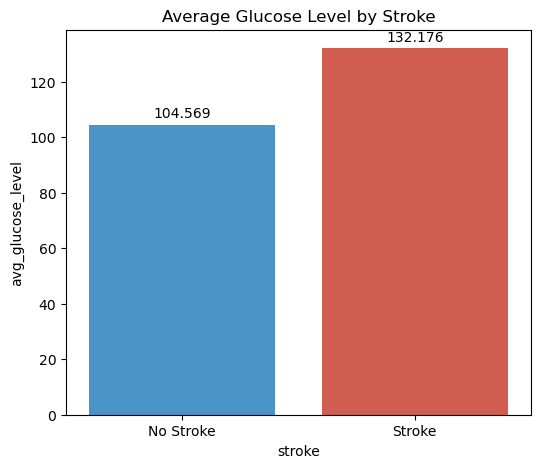

In [ ]:
plt.figure(figsize=(6,5))

# 1. Assign the barplot to a variable 'ax'
ax = sns.barplot(data=df, x="stroke", y="avg_glucose_level", palette=["#3498db", "#e74c3c"], errorbar=None)

plt.xticks([0, 1], ["No Stroke", "Stroke"])
plt.title("Average Glucose Level by Stroke")

# 2. Add the labels using the first container group
ax.bar_label(ax.containers[0], padding=3)
ax.bar_label(ax.containers[1], padding=3)

plt.show()

### Business Insight

Patients with stroke exhibit a noticeably higher average glucose level (132.18) than patients without stroke (104.57), suggesting that elevated blood glucose may be associated with stroke occurrence.

### Business Recommendation

Healthcare providers should emphasize regular glucose monitoring and diabetes management as part of stroke prevention strategies.



### 8. What is the smoking status distribution of patients?

Smoking is a recognized lifestyle factor associated with cardiovascular diseases and stroke.

C:\Users\Elena\AppData\Local\Temp\ipykernel_9504\1275744743.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="smoking_status", palette="Blues_r")


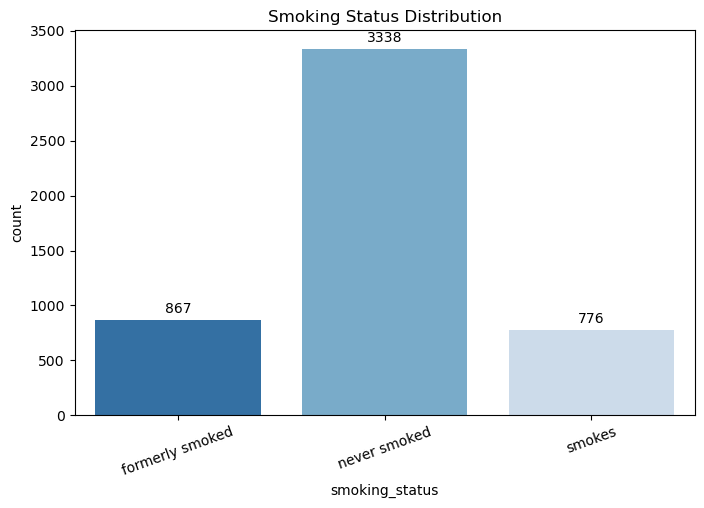

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x="smoking_status", palette="Blues_r")

plt.title("Smoking Status Distribution")
plt.xticks(rotation=20)

ax.bar_label(ax.containers[0], padding=3)

ax.bar_label(ax.containers[1], padding=3)

ax.bar_label(ax.containers[2], padding=3)

plt.show()

### Business Insight

The dataset includes patients with diverse smoking histories. Former smokers represent a relatively larger proportion among stroke patients compared to non-stroke patients.

### Business Recommendation

Smoking cessation programs and long-term lifestyle counseling should remain important components of preventive healthcare initiatives.



### 9. Is hypertension more common among stroke patients?

Hypertension is one of the leading medical conditions associated with stroke risk.

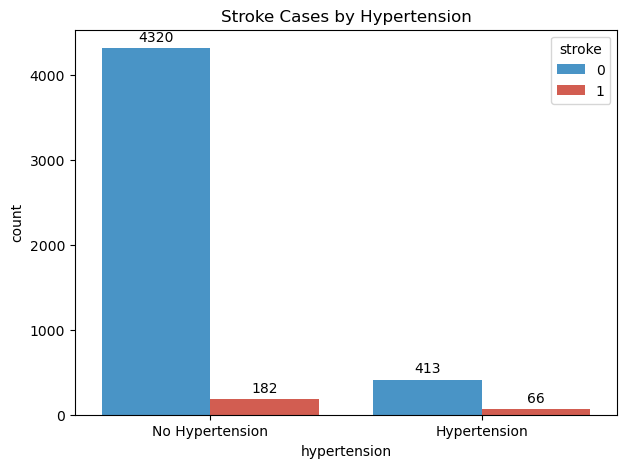

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x="hypertension", hue="stroke", palette=["#3498db", "#e74c3c"])
plt.xticks([0, 1], ["No Hypertension", "Hypertension"])
plt.title("Stroke Cases by Hypertension")


for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

### Business Insight

Hypertension is considerably more prevalent among patients who experienced a stroke than among those who did not, highlighting its importance as a stroke-related risk factor.

### Business Recommendation

Routine blood pressure monitoring and early hypertension management should be prioritized to reduce stroke incidence.



### 10. Is heart disease associated with stroke occurrence?

Cardiovascular conditions often increase the likelihood of stroke and therefore require closer examination.

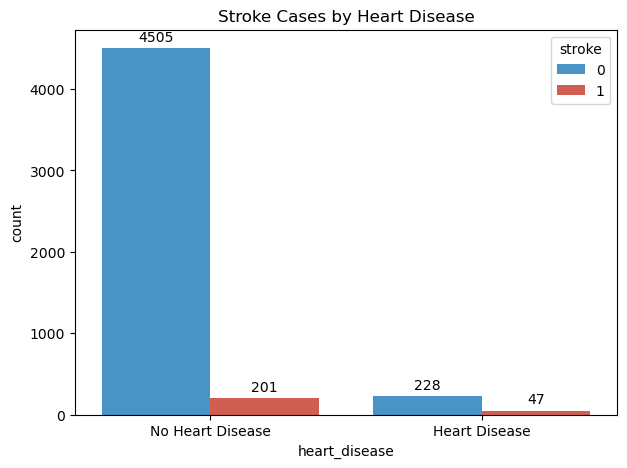

In [ ]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x="heart_disease", hue="stroke", palette=["#3498db", "#e74c3c"])
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.title("Stroke Cases by Heart Disease")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

### Business Insight

Heart disease occurs more frequently among stroke patients than among non-stroke patients, indicating a strong association between cardiovascular health and stroke occurrence.

### Business Recommendation

Hospitals should integrate cardiovascular disease management with stroke prevention programs to improve patient outcomes.



### 11. Which numerical variables show the strongest relationships with stroke?

A correlation heatmap provides an overview of linear relationships between numerical variables in the dataset.

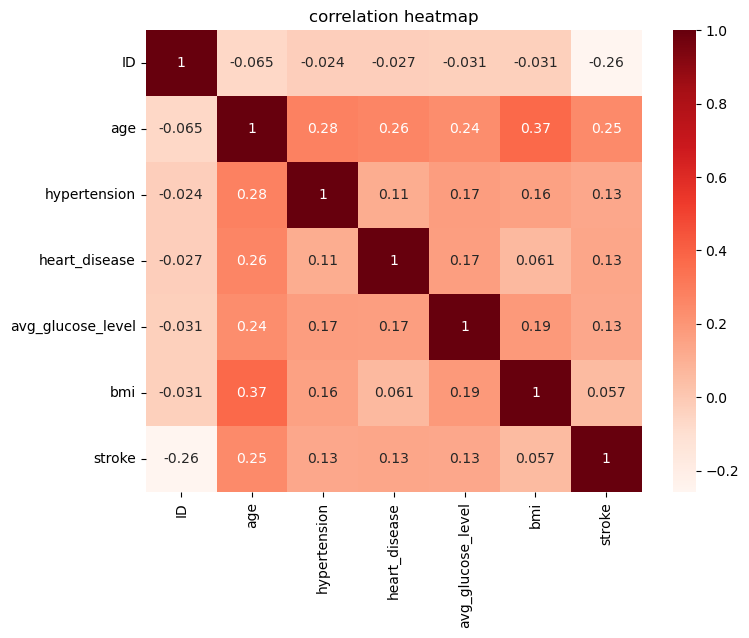

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot= True, cmap="Reds")
plt.title("correlation heatmap")
plt.show()

### Business Insight

Age, hypertension, heart disease, and average glucose level demonstrate stronger positive relationships with stroke than other variables. No single variable alone explains stroke occurrence, indicating that stroke is influenced by multiple interacting risk factors.

### Business Recommendation

Healthcare providers should adopt comprehensive risk assessment models that combine demographic and clinical information instead of relying on a single health indicator.


---

# Conclusion

This exploratory data analysis identified several characteristics associated with stroke occurrence. Patients diagnosed with stroke were generally older and had higher average glucose levels than those without stroke. Hypertension and heart disease were also considerably more prevalent among stroke patients, while BMI showed a moderate association.

These findings highlight the importance of combining demographic and clinical information when assessing stroke risk. The insights generated from this analysis can support healthcare professionals in preventive screening, early intervention, and healthcare resource planning.

---

## Future Scope

This project can be extended by:

- Developing a machine learning model to predict stroke risk.
- Evaluating feature importance using predictive algorithms.
- Deploying an interactive web application for real-time stroke risk assessment.
- Integrating additional clinical data to improve prediction accuracy.Conclusion 

This analysis identified several patient characteristics associated with stroke occurrence. Stroke patients were generally older and exhibited higher average glucose levels than non-stroke patients. Hypertension and heart disease were considerably more prevalent among individuals who experienced a stroke, while BMI showed a weaker association. These findings suggest that healthcare organizations should prioritize preventive screening and monitoring for elderly patients and those with cardiovascular conditions or elevated glucose levels. The interactive Power BI dashboard developed as part of this project enables healthcare professionals to explore these patterns and support data-driven decision-making for resource planning.
_________________________________________________________________________________________________________________________________________________________________________________________________